Picard 000: rel_change=9.997e-01  |res|_inf=3.000e-01  lambda[min,max]=[0.333,0.333]
Picard 005: rel_change=2.214e-03  |res|_inf=1.020e-02  lambda[min,max]=[0.284,0.333]
Picard 010: rel_change=9.709e-06  |res|_inf=1.088e-04  lambda[min,max]=[0.284,0.333]
Picard 015: rel_change=6.802e-08  |res|_inf=1.125e-06  lambda[min,max]=[0.284,0.333]
Picard 020: rel_change=6.178e-10  |res|_inf=1.153e-08  lambda[min,max]=[0.284,0.333]


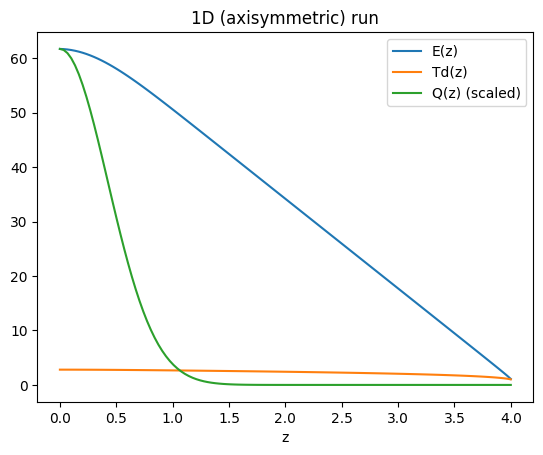

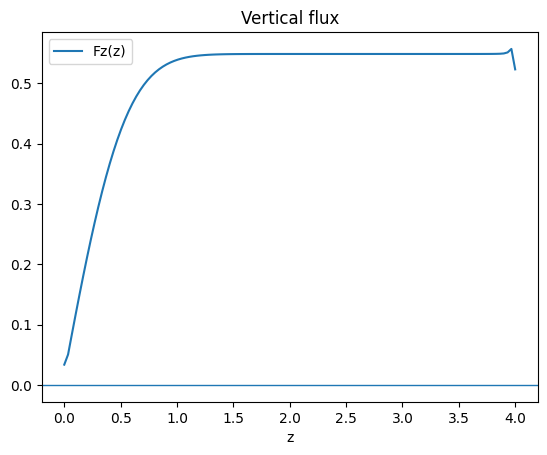

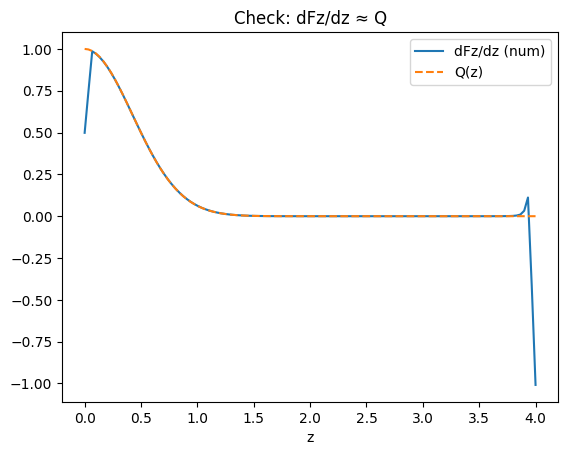

In [3]:
# Minimal nonlinear FLD solver in (phi,z) with Levermore–Pomraning flux limiter
# - Solves: (1/Rcyl) dFphi/dphi + dFz/dz = Q(phi,z)
# - Closure: Fphi = -(D/Rcyl) dE/dphi ,  Fz = -D dE/dz
# - D = c * lambda / (rho * kappa_R)
# - lambda(R) = (1/R)*(coth R - 1/R)  (Levermore–Pomraning)
# - R = |∇E| / (rho*kappa_R*E)
#
# BCs:
# - phi periodic
# - midplane (z=0): Fz = 0  (symmetry)
# - top (z=zmax): two-stream-like Robin: Fz = alpha * c * E  (default alpha=1/2)
#
# For your 1D MEMO regression: set Nphi=1 and compare with your own 1D integration.
# NOTE: The top BC coefficient alpha may need tuning to exactly match the Dullemond MEMO choice.

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# -----------------------------
# Levermore–Pomraning limiter
# -----------------------------
def lambda_LP(R):
    """Levermore–Pomraning flux limiter: lambda = (1/R)(coth R - 1/R)."""
    R = np.asarray(R)
    out = np.empty_like(R, dtype=float)
    # small-R series: lambda ~ 1/3 - R^2/45 + ...
    small = R < 1e-6
    out[small] = 1.0/3.0 - (R[small]**2)/45.0
    # general
    x = R[~small]
    out[~small] = (1.0/x) * (1.0/np.tanh(x) - 1.0/x)
    return out

# -----------------------------
# Helpers
# -----------------------------
def idx(i, j, Nz, Nphi):
    return i*Nphi + j

def assemble_linear_system(Ek, Q, z, phi, Rcyl, rho, kappaR, c, alpha_top):
    """
    Assemble A(Ek) * Enew = b for Picard step: -div(D(Ek) grad Enew) = Q,
    with FV-like 5-pt stencil in (phi,z), cell-centered.
    """
    Nz, Nphi = Ek.shape
    dz = z[1] - z[0]
    dphi = phi[1] - phi[0] if Nphi > 1 else 2*np.pi

    # Compute gradients of Ek (cell-centered) for limiter
    # dE/dz: one-sided at boundaries, centered inside
    dEdz = np.zeros_like(Ek)
    dEdz[1:-1,:] = (Ek[2:,:] - Ek[:-2,:])/(2*dz)
    dEdz[0,:]    = (Ek[1,:] - Ek[0,:]) / dz     # near midplane
    dEdz[-1,:]   = (Ek[-1,:] - Ek[-2,:]) / dz   # near top

    # dE/dphi (periodic): centered
    dEdphi = np.zeros_like(Ek)
    if Nphi > 1:
        dEdphi[:, :] = (np.roll(Ek, -1, axis=1) - np.roll(Ek, 1, axis=1)) / (2*dphi)
    else:
        dEdphi[:, :] = 0.0

    # |grad E| in cylindrical metric: |∇E| = sqrt( (1/Rcyl dE/dphi)^2 + (dE/dz)^2 )
    gradmag = np.sqrt((dEdphi/Rcyl)**2 + dEdz**2)

    # R = |∇E| / (rho*kappaR*E)
    E_safe = np.maximum(Ek, 1e-30)
    Rlim = gradmag / (rho*kappaR*E_safe + 1e-30)

    lam = lambda_LP(Rlim)
    D = c * lam / (rho * kappaR)  # cell-centered D

    # Face D (simple averaging; harmonic is also fine)
    # z-faces: D_{i+1/2} between i and i+1
    Dz_up = np.zeros_like(Ek)  # face between i and i+1, stored at i (up face)
    Dz_up[:-1,:] = 0.5*(D[:-1,:] + D[1:,:])
    # phi-faces: D_{j+1/2} between j and j+1
    Dp_rt = np.zeros_like(Ek)  # face between j and j+1, stored at j (right face)
    if Nphi > 1:
        Dp_rt[:,:] = 0.5*(D + np.roll(D, -1, axis=1))
    else:
        Dp_rt[:,:] = 0.0

    # Build sparse matrix
    N = Nz*Nphi
    rows, cols, vals = [], [], []
    b = Q.reshape(-1).copy()

    inv_dz2 = 1.0/(dz*dz)
    inv_dphi2 = 1.0/(dphi*dphi) if Nphi > 1 else 0.0
    inv_Rcyl2 = 1.0/(Rcyl*Rcyl)

    for i in range(Nz):
        for j in range(Nphi):
            p = idx(i,j,Nz,Nphi)
            diag = 0.0

            # --- z direction fluxes ---
            # Down face (i-1/2):
            if i == 0:
                # midplane symmetry: Fz=0 => no contribution
                pass
            else:
                Dz_dn = Dz_up[i-1, j]  # face between i-1 and i
                # contribution: -(F_up - F_dn)/dz with F = -D dE/dz
                # leads to +Dz_dn/dz^2 * (E_i - E_{i-1})
                diag += Dz_dn*inv_dz2
                rows.append(p); cols.append(idx(i-1,j,Nz,Nphi)); vals.append(-Dz_dn*inv_dz2)

            # Up face (i+1/2):
            if i == Nz-1:
                # top Robin: Fz(top) = alpha_top * c * E_top
                # divergence term includes (F_top - F_dn)/dz.
                # Bring F_top to LHS: + (alpha_top*c)/dz * E_top
                diag += (alpha_top*c)/dz
            else:
                Dz_u = Dz_up[i, j]
                diag += Dz_u*inv_dz2
                rows.append(p); cols.append(idx(i+1,j,Nz,Nphi)); vals.append(-Dz_u*inv_dz2)

            # --- phi direction fluxes (periodic) ---
            if Nphi > 1:
                # right face (j+1/2) uses Dp_rt[i,j]
                Dr = Dp_rt[i, j]
                jl = (j-1) % Nphi
                jr = (j+1) % Nphi

                # left face (j-1/2) is Dp_rt[i,j-1]
                Dl = Dp_rt[i, jl]

                # Metric: term is (1/Rcyl) d/dphi ( -D/Rcyl dE/dphi )
                # -> like diffusion in phi with coefficient D/Rcyl^2
                coef_r = Dr * inv_dphi2 * inv_Rcyl2
                coef_l = Dl * inv_dphi2 * inv_Rcyl2

                diag += (coef_r + coef_l)
                rows.append(p); cols.append(idx(i, jr, Nz, Nphi)); vals.append(-coef_r)
                rows.append(p); cols.append(idx(i, jl, Nz, Nphi)); vals.append(-coef_l)

            # diagonal entry
            rows.append(p); cols.append(p); vals.append(diag)

    A = sp.csr_matrix((vals, (rows, cols)), shape=(N, N))
    return A, b, D, lam, Rlim

def solve_fld(Q_func, Nz=80, Nphi=64, zmax=4.0, Rcyl=1.0,
              rho=1.0, kappaR=10.0, kappaP=10.0, c=1.0, a_rad=1.0,
              alpha_top=0.5,  # two-stream-ish: F = (1/2)cE
              max_picard=80, tol=1e-8, omega=0.6, verbose=True):
    """
    Solve nonlinear FLD for E with Picard iterations: -div(D(Ek) grad Enew) = Q.
    Also returns a Td diagnostic from a Td^4 relation implied by steady dust balance:
      a*Td^4 = E + Q/(rho*kappaP*c)
    (This corresponds to enforcing rho*kappaP*c(aTd^4 - E) = Q in the RT equation.)
    """
    # grids
    z = np.linspace(0.0, zmax, Nz)           # cell centers including boundary (simple)
    phi = np.linspace(0.0, 2*np.pi, Nphi, endpoint=False) if Nphi > 1 else np.array([0.0])

    # build Q on grid
    Z, PHI = np.meshgrid(z, phi, indexing="ij")
    Q = Q_func(PHI, Z)  # shape (Nz, Nphi)

    # initial guess: small positive constant + a bit of Q to break symmetry
    E = np.ones((Nz, Nphi))*1e-2 + 1e-3*np.maximum(Q, 0)

    for k in range(max_picard):
        A, b, Dk, lamk, Rk = assemble_linear_system(E, Q, z, phi, Rcyl, rho, kappaR, c, alpha_top)

        # Solve linear system
        E_new = spla.spsolve(A, b).reshape(Nz, Nphi)

        # positivity
        E_new = np.maximum(E_new, 1e-30)

        # under-relax
        E_next = (1-omega)*E + omega*E_new

        # convergence check
        rel = np.max(np.abs(E_next - E) / np.maximum(np.abs(E_next), 1e-30))
        if verbose and (k % 5 == 0 or k == max_picard-1):
            # compute a residual norm (quick)
            res = A.dot(E_next.reshape(-1)) - b
            res_inf = np.max(np.abs(res))
            print(f"Picard {k:03d}: rel_change={rel:.3e}  |res|_inf={res_inf:.3e}  lambda[min,max]=[{lamk.min():.3g},{lamk.max():.3g}]")

        E = E_next
        if rel < tol:
            break

    # Diagnostic Td from enforcing source matching:
    # rho*kappaP*c(a Td^4 - E) = Q  => a Td^4 = E + Q/(rho*kappaP*c)
    Td4 = (E + Q/(rho*kappaP*c + 1e-30)) / a_rad
    Td4 = np.maximum(Td4, 0.0)
    Td = Td4**0.25

    return dict(E=E, Td=Td, Q=Q, z=z, phi=phi, Rcyl=Rcyl, rho=rho, kappaR=kappaR, kappaP=kappaP, c=c, a_rad=a_rad)

# ---------------------------------------------------------
# Example 1: 1D test (axisymmetric): Nphi=1
# ---------------------------------------------------------
def Q_1D(phi, z):
    # simple Gaussian heating in z
    return 1.0*np.exp(-(z/0.6)**2)

sol1D = solve_fld(Q_1D, Nz=120, Nphi=1, zmax=4.0, kappaR=10.0, kappaP=10.0, alpha_top=0.5,
                  max_picard=100, tol=1e-9, omega=0.7, verbose=True)

z = sol1D["z"]
E = sol1D["E"][:,0]
Td = sol1D["Td"][:,0]
Qz = sol1D["Q"][:,0]

plt.figure()
plt.plot(z, E, label="E(z)")
plt.plot(z, Td, label="Td(z)")
plt.plot(z, Qz/Qz.max()*E.max(), label="Q(z) (scaled)")
plt.xlabel("z"); plt.legend(); plt.title("1D (axisymmetric) run")
plt.show()

# Compute and plot Fz = -D dE/dz and check dF/dz ~ Q (discretely)
# (Using the last-iteration D recomputed from the final E)
def compute_Fz(E2d, z, Rcyl, rho, kappaR, c):
    Nz, Nphi = E2d.shape
    dz = z[1]-z[0]
    # gradients
    dEdz = np.zeros_like(E2d)
    dEdz[1:-1,:] = (E2d[2:,:]-E2d[:-2,:])/(2*dz)
    dEdz[0,:] = (E2d[1,:]-E2d[0,:])/dz
    dEdz[-1,:] = (E2d[-1,:]-E2d[-2,:])/dz

    # |grad E| approx (no phi part for Nphi=1)
    gradmag = np.abs(dEdz)
    E_safe = np.maximum(E2d, 1e-30)
    Rlim = gradmag/(rho*kappaR*E_safe + 1e-30)
    lam = lambda_LP(Rlim)
    D = c*lam/(rho*kappaR)
    Fz = -D*dEdz
    return Fz[:,0], D[:,0], lam[:,0], Rlim[:,0]

Fz, D, lam, Rlim = compute_Fz(sol1D["E"], sol1D["z"], sol1D["Rcyl"], sol1D["rho"], sol1D["kappaR"], sol1D["c"])
dFdz = np.gradient(Fz, z)

plt.figure()
plt.plot(z, Fz, label="Fz(z)")
plt.axhline(0, lw=1)
plt.xlabel("z"); plt.legend(); plt.title("Vertical flux")
plt.show()

plt.figure()
plt.plot(z, dFdz, label="dFz/dz (num)")
plt.plot(z, Qz, "--", label="Q(z)")
plt.xlabel("z"); plt.legend(); plt.title("Check: dFz/dz ≈ Q")
plt.show()



Picard 000: rel_change=9.997e-01  |res|_inf=6.799e-01  lambda[min,max]=[0.333,0.333]
Picard 005: rel_change=7.044e-03  |res|_inf=1.704e-02  lambda[min,max]=[0.285,0.333]
Picard 010: rel_change=8.607e-05  |res|_inf=4.401e-04  lambda[min,max]=[0.285,0.333]
Picard 015: rel_change=1.240e-06  |res|_inf=1.118e-05  lambda[min,max]=[0.285,0.333]
Picard 020: rel_change=2.169e-08  |res|_inf=2.865e-07  lambda[min,max]=[0.285,0.333]


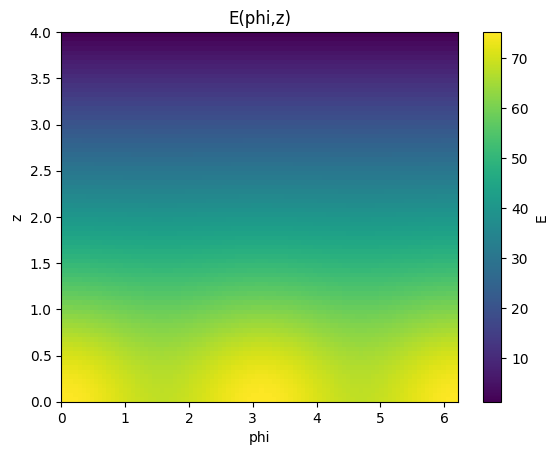

In [4]:

# ---------------------------------------------------------
# Example 2: 2D test (phi,z): periodic phi
# ---------------------------------------------------------
def Q_2D(phi, z):
    # a shadow/heating pattern: cos(m phi) times a vertical Gaussian
    m = 2
    return (1.0 + 0.7*np.cos(m*phi)) * np.exp(-(z/0.7)**2)

sol2D = solve_fld(Q_2D, Nz=80, Nphi=96, zmax=4.0, kappaR=10.0, kappaP=10.0, alpha_top=0.5,
                  max_picard=120, tol=1e-8, omega=0.6, verbose=True)

E2 = sol2D["E"]
phi = sol2D["phi"]
z = sol2D["z"]

# Show E(phi,z) as an image
plt.figure()
plt.imshow(E2, aspect="auto", origin="lower",
           extent=[phi.min(), phi.max(), z.min(), z.max()])
plt.colorbar(label="E")
plt.xlabel("phi"); plt.ylabel("z"); plt.title("E(phi,z)")
plt.show()

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# ============================================================
# Constants (cgs)
# ============================================================
AU   = 1.495978707e13
RSUN = 6.957e10
SIGMA_SB = 5.670374419e-5
PI = np.pi
c_light = 2.99792458e10
a_rad = 4.0 * SIGMA_SB / c_light  # radiation constant

# ============================================================
# Your disk setup (as provided)
# ============================================================
Teff   = 3000.0
Rstar  = 2.0 * RSUN

Sigma_1AU = 10.
pSigma    = 1.0

R_cyl = 50 * AU
Sigma = Sigma_1AU * (R_cyl / AU) ** (-pSigma)

Hscale = 0.1 * R_cyl

psi = 1.0 / np.sqrt(3.0)  # you defined; not used directly in this minimal BC
mu0 = 0.05

# Grid (upper half)
nz = 400
zmax = 12.0 * Hscale
p_stretch = 1.0
s = np.linspace(0.0, 1.0, nz)
z = zmax * s**p_stretch

rho0 = Sigma / (np.sqrt(2*PI) * Hscale)
rho = rho0 * np.exp(-0.5 * (z/Hscale)**2)

# ============================================================
# Opacities (placeholder power laws)
# ============================================================
Tref = 100.0
kappaP0 = 100.0
kappaR0 = 100.0
betaP  = 1.0
betaR  = 1.0

def kappaP(T):
    T = np.maximum(T, 1.0)
    return kappaP0 * (T/Tref)**betaP

def kappaR(T):
    T = np.maximum(T, 1.0)
    return kappaR0 * (T/Tref)**betaR

kappa_star = kappaP(Teff)

def stellar_heating_q(rho_1d, z_1d, kappa_star, F_star, mu0):
    integrand = rho_1d * kappa_star
    tau_top = np.zeros_like(z_1d)
    for i in range(len(z_1d)-2, -1, -1):
        tau_top[i] = tau_top[i+1] + 0.5*(integrand[i]+integrand[i+1])*(z_1d[i+1]-z_1d[i])
    q = rho_1d * kappa_star * F_star * np.exp(-tau_top/np.maximum(mu0, 1e-12))
    return q, tau_top

# Stellar flux at R (toy)
F_star = SIGMA_SB * Teff**4 * (Rstar / R_cyl)**2
qz, tauz = stellar_heating_q(rho, z, kappa_star, F_star, mu0)  # 1D heating

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ---------- Levermore–Pomraning limiter ----------
def lambda_LP(R):
    R = np.asarray(R)
    out = np.empty_like(R, dtype=float)
    small = R < 1e-6
    out[small] = 1.0/3.0 - (R[small]**2)/45.0
    x = R[~small]
    out[~small] = (1.0/x) * (1.0/np.tanh(x) - 1.0/x)
    return out

# ---------- local Td solve from Q = rho*kP*c*(a Td^4 - E) with kP(Td) ----------
def solve_Td_from_EQ(E, Q, rho, kappaP_func, c_light, a_rad,
                     Td_init=None, n_iter=30, tol=1e-8):
    """
    Solve per cell:
        Q = rho*kP(Td)*c*(a*Td^4 - E)
    for Td >= 0 by fixed point on Td.
    """
    E = np.maximum(E, 0.0)
    Q = np.asarray(Q)

    if Td_init is None:
        # crude guess: ignore Q term
        Td = np.maximum(E/a_rad, 0.0)**0.25
        Td = np.maximum(Td, 1.0)
    else:
        Td = np.maximum(Td_init, 1.0)

    # Fixed point: a Td^4 = E + Q/(rho*kP(Td)*c)
    for _ in range(n_iter):
        kP = kappaP_func(Td)
        rhs = E + Q/(rho * kP * c_light + 1e-60)
        Td_new = np.maximum(rhs/a_rad, 0.0)**0.25
        Td_new = np.maximum(Td_new, 1.0)
        rel = np.max(np.abs(Td_new - Td)/np.maximum(Td_new, 1.0))
        Td = Td_new
        if rel < tol:
            break
    return Td

# ---------- 2D assembly (Picard) with kappaR field ----------
def assemble_2d_picard(Ek, Q, z, phi, Rcyl, rho_z, kappaR_2d, alpha_top, c_light):
    Nz, Nphi = Ek.shape
    dphi = (phi[1]-phi[0]) if Nphi > 1 else 2*np.pi

    # gradients of Ek for limiter
    dEdphi = np.zeros_like(Ek)
    #if Nphi > 1:
    #    dEdphi = (np.roll(Ek, -1, axis=1) - np.roll(Ek, 1, axis=1)) / (2*dphi)

    dEdz = np.zeros_like(Ek)
    dEdz[1:-1,:] = (Ek[2:,:] - Ek[:-2,:]) / (z[2:,None] - z[:-2,None])
    dEdz[0,:]    = (Ek[1,:] - Ek[0,:]) / (z[1]-z[0] + 1e-60)
    dEdz[-1,:]   = (Ek[-1,:] - Ek[-2,:]) / (z[-1]-z[-2] + 1e-60)

    gradmag = np.sqrt((dEdphi/Rcyl)**2 + dEdz**2)

    rho2d = rho_z[:,None] * np.ones((Nz, Nphi))
    E_safe = np.maximum(Ek, 1e-60)
    kR = np.maximum(kappaR_2d, 1e-60)

    Rlim = gradmag / (rho2d * kR * E_safe + 1e-60)
    lam = lambda_LP(Rlim)
    D = c_light * lam / (rho2d * kR + 1e-60)

    # face diffusivities (harmonic)
    Dz = 2*D[:-1,:]*D[1:,:] / (D[:-1,:] + D[1:,:] + 1e-60)
    if Nphi > 1:
        Dp = 2*D*np.roll(D, -1, axis=1) / (D + np.roll(D, -1, axis=1) + 1e-60)
    else:
        Dp = np.zeros_like(D)

    def I(i,j): return i*Nphi + j
    N = Nz*Nphi
    rows, cols, vals = [], [], []
    b = Q.reshape(-1).copy()

    # control-volume thickness in z (nonuniform)
    dz_cv = np.zeros(Nz)
    dz_cv[0]    = 0.5*(z[1]-z[0])
    dz_cv[-1]   = 0.5*(z[-1]-z[-2])
    dz_cv[1:-1] = 0.5*(z[2:]-z[:-2])

    for i in range(Nz):
        for j in range(Nphi):
            p = I(i,j)
            diag = 0.0

            # z part: (Fz_up - Fz_dn)/dz_cv
            if i > 0:
                dzm = z[i] - z[i-1]
                Dm = Dz[i-1, j]
                coef = Dm / (dzm * dz_cv[i])
                diag += coef
                rows.append(p); cols.append(I(i-1,j)); vals.append(-coef)

            if i == Nz-1:
                # top Robin: Fz = alpha*c*E
                diag += (alpha_top * c_light) / dz_cv[i]
            else:
                dzp = z[i+1] - z[i]
                Dup = Dz[i, j]
                coef = Dup / (dzp * dz_cv[i])
                diag += coef
                rows.append(p); cols.append(I(i+1,j)); vals.append(-coef)

            # phi part: (1/Rcyl)*(Fphi_r - Fphi_l)/dphi
            if Nphi > 1:
                jl = (j-1) % Nphi
                jr = (j+1) % Nphi
                Dr = Dp[i, j]
                Dl = Dp[i, jl]
                coef_r = Dr / (Rcyl*Rcyl * dphi*dphi)
                coef_l = Dl / (Rcyl*Rcyl * dphi*dphi)
                diag += (coef_r + coef_l)
                rows.append(p); cols.append(I(i,jr)); vals.append(-coef_r)
                rows.append(p); cols.append(I(i,jl)); vals.append(-coef_l)

            rows.append(p); cols.append(p); vals.append(diag)

    A = sp.csr_matrix((vals, (rows, cols)), shape=(N, N))
    return A, b, lam, Rlim

def solve_fld_2d_with_kappaT(Q2d, z, phi, Rcyl, rho_z,
                            kappaP_func, kappaR_func,
                            c_light, a_rad,
                            alpha_top=0.5,
                            max_outer=80,            # outer: update Td, kappa
                            max_picard_E=1,          # inner Picard steps for E per outer
                            omega_E=0.6,
                            axisym_enforce=False,    # True for your axisymmetric regression
                            verbose=True):

    Nz, Nphi = Q2d.shape
    # init E, Td
    E = np.ones((Nz, Nphi))*1e-30 + 1e-12*np.maximum(Q2d, 0)
    Td = np.ones_like(E)*100.0

    for outer in range(max_outer):
        # Update Td from implicit steady balance, then kappa fields
        rho2d = rho_z[:,None] * np.ones((Nz, Nphi))
        Td_new = solve_Td_from_EQ(E, Q2d, rho2d, kappaP_func, c_light, a_rad,
                                  Td_init=Td, n_iter=40, tol=1e-8)
        kR_2d = kappaR_func(Td_new)

        # A few Picard steps for E using frozen kR_2d (and limiter uses Ek)
        E_old_outer = E.copy()
        for _ in range(max_picard_E):
            A, b, lam, Rlim = assemble_2d_picard(E, Q2d, z, phi, Rcyl, rho_z, kR_2d, alpha_top, c_light)
            E_lin = spla.spsolve(A, b).reshape(Nz, Nphi)
            E_lin = np.maximum(E_lin, 1e-60)
            E = (1-omega_E)*E + omega_E*E_lin

            if axisym_enforce:
                # enforce m=0 manifold (for axisymmetric heating regression)
                Ebar = E.mean(axis=1, keepdims=True)
                E = np.repeat(Ebar, Nphi, axis=1)

        Td = Td_new

        # convergence diagnostics
        relE = np.max(np.abs(E - E_old_outer)/np.maximum(np.abs(E), 1e-60))
        phi_std = np.max(np.std(E, axis=1)/np.maximum(np.mean(E, axis=1), 1e-60))

        if verbose and (outer % 5 == 0 or outer == max_outer-1):
            print(f"[outer {outer:03d}] relE={relE:.3e}  max(std/mean over phi)={phi_std:.3e}  "
                  f"lambda[min,max]=[{lam.min():.3g},{lam.max():.3g}]  R[max]={Rlim.max():.3g}")

        if relE < 1e-8:
            break

    return E, Td


/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_74155/3886383136.py:227: MatrixRankWarning: Matrix is exactly singular
  E_lin = spla.spsolve(A, b).reshape(Nz, Nphi)


[outer 000] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[7.94e-10,0.333]  R[max]=1.26e+09
[outer 005] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 010] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 015] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 020] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 025] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 030] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 035] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 040] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 045] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 050] relE=nan  max(std/mean over phi)=nan  lambda[min,max]=[nan,nan]  R[max]=nan
[outer 055] relE=nan

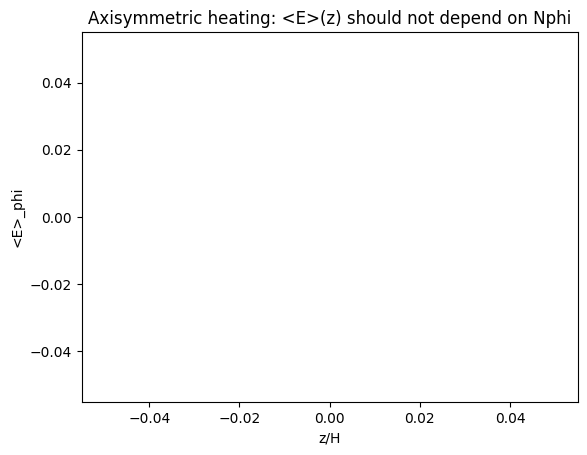

In [60]:
# 2D grid
Nphi = 64
phi = np.linspace(0, 2*np.pi, Nphi, endpoint=False)

# axisymmetric heating first (still 2D framework)
Q2d = qz[:,None] * np.ones((len(z), Nphi))

# Solve with temperature-dependent opacities
E2d, Td2d = solve_fld_2d_with_kappaT(
    Q2d * (1+np.cos(phi)), z, phi, R_cyl, rho,
    kappaP_func=kappaP, kappaR_func=kappaR,
    c_light=c_light, a_rad=a_rad,
    alpha_top=np.sqrt(1./3.),           # tune to match your MEMO/two-stream BC
    max_outer=80,
    max_picard_E=1,
    omega_E=0.6,
    axisym_enforce=False,     # IMPORTANT for your axisymmetric regression
    verbose=True
)

Ebar = E2d.mean(axis=1)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(z/AU, Ebar)
plt.xlabel("z/H"); plt.ylabel("<E>_phi")
plt.title("Axisymmetric heating: <E>(z) should not depend on Nphi")
plt.show()


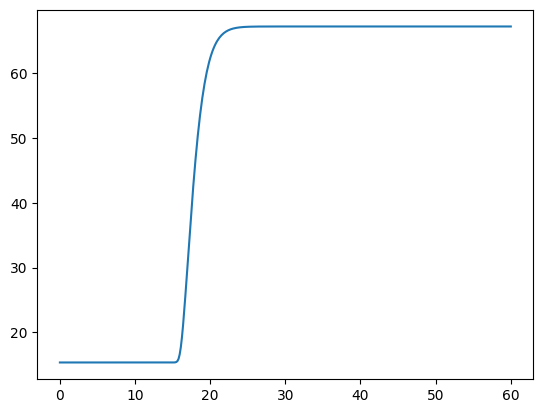

In [54]:
plt.plot(z/AU, Td2d.mean(axis=1))

In [55]:
C_LIGHT  = 2.99792458e10
SIGMA_SB = 5.670374419e-5
PI       = np.pi
A_RAD    = 4.0 * SIGMA_SB / C_LIGHT  # a_R

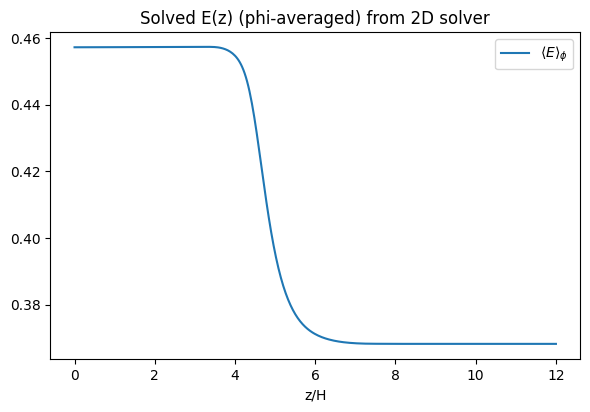

In [56]:
plt.figure(figsize=(6,4))
plt.plot(z/Hscale, Ebar *  C_LIGHT/(4.*np.pi), label=r'$\langle E\rangle_\phi$')
plt.xlabel("z/H"); plt.legend(); plt.tight_layout()
plt.title("Solved E(z) (phi-averaged) from 2D solver")
plt.show()

In [1]:
plt.pcolormesh(phi, z/Hscale, Td2d,)
plt.colorbar()

NameError: name 'plt' is not defined

In [2]:
plt.imshow(Td2d)

NameError: name 'plt' is not defined

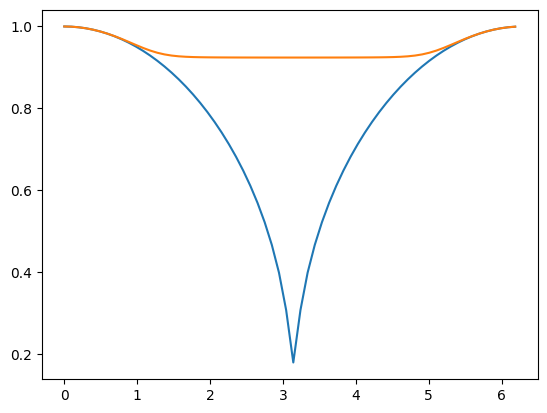

In [58]:
plt.plot(phi, Td2d[-1,:]/Td2d[-1,:].max())
plt.plot(phi, Td2d[0,:]/Td2d[0,:].max())

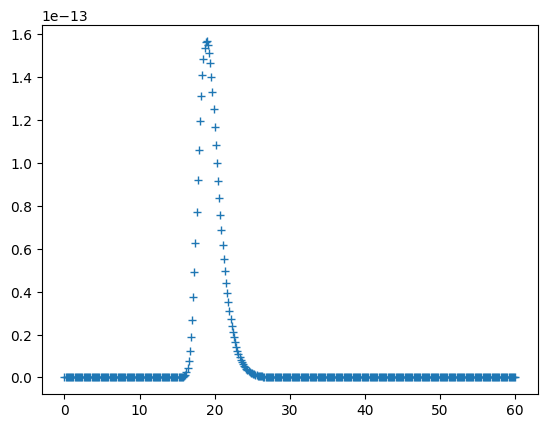

In [26]:
plt.plot(z/AU, np.mean(Q2d, axis=1), '+')